# 종합실습 2 데이터 전처리

- scale : 목표변수 (산화철 불량/양품 여부)
- plate_no : plate 번호
- rolling_date : 열연작업시작
- spec_long : 제품 규격
- spec_country : 제품 규격 기준국
- steel_kind : 강종
- pt_thick : 후판 지시두께 (고객 요구 두께)
- pt_width : 후판 지시폭 (고객 요구 폭)
- pt_length : 후판 지시길이 (고개요구 길이)
- hsb : Hot Sacle Braker 적용 여부 
- fur_no : 가열로 호기
- fur_input_row : 가열로 장입열
- fur_heat_temp : 가열로 가열대 소재온도
- fur_heat_time : 가열로 가열대 재로시간
- fur_soak_temp : 가열로 균열대 소재온도
- fur_soak_time : 가열로 재로시간
- fur_total_time : 가열로 총 재로시간 (예열, 가열대, 균열대 시간 총합)
- rolling_method : 압연방법
- rolling_temp : 압연온도
- descaling_count : 압연 디스케일링 횟수
- work_group : 작업조
- fur_ex_temp : 균열대 이탈직후 온도

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 데이터 불러오기

In [2]:
df_raw = pd.read_csv("../../01.files/02.Bigsata_analysis/SCALE불량.csv", encoding = 'euc-kr')
df_raw.head()

,plate_no,rolling_date,scale,spec_long,spec_country,steel_kind,pt_thick,pt_width,pt_length,hsb,...,fur_input_row,fur_heat_temp,fur_heat_time,fur_soak_temp,fur_soak_time,fur_total_time,rolling_method,rolling_temp,descaling_count,work_group
0,PLT_1001,03JAN2023:07:07:53,양품,AB/EH32-TM,미국,T,32,3700,15100,적용,...,1열,1144,116,1133,59,259,TMCP(온도제어),934,8,1조
1,PLT_1002,03JAN2023:07:21:22,양품,AB/EH32-TM,미국,T,32,3700,15100,적용,...,2열,1144,122,1135,53,238,TMCP(온도제어),937,8,1조
2,PLT_1003,03JAN2023:07:31:15,양품,NV-E36-TM,영국,T,33,3600,19200,적용,...,1열,1129,116,1121,55,258,TMCP(온도제어),889,8,1조
3,PLT_1004,03JAN2023:07:41:01,양품,NV-E36-TM,영국,T,33,3600,19200,적용,...,2열,1152,125,1127,68,266,TMCP(온도제어),885,8,1조
4,PLT_1005,03JAN2023:07:52:40,양품,BV-EH36-TM,프랑스,T,38,3100,13300,적용,...,1열,1140,134,1128,48,246,TMCP(온도제어),873,8,1조


In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   plate_no         1000 non-null   object
 1   rolling_date     1000 non-null   object
 2   scale            1000 non-null   object
 3   spec_long        1000 non-null   object
 4   spec_country     1000 non-null   object
 5   steel_kind       1000 non-null   object
 6   pt_thick         1000 non-null   int64 
 7   pt_width         1000 non-null   int64 
 8   pt_length        1000 non-null   int64 
 9   hsb              1000 non-null   object
 10  fur_no           1000 non-null   object
 11  fur_input_row    1000 non-null   object
 12  fur_heat_temp    1000 non-null   int64 
 13  fur_heat_time    1000 non-null   int64 
 14  fur_soak_temp    1000 non-null   int64 
 15  fur_soak_time    1000 non-null   int64 
 16  fur_total_time   1000 non-null   int64 
 17  rolling_method   1000 non-null   o

In [4]:
df_raw.describe()

,pt_thick,pt_width,pt_length,fur_heat_temp,fur_heat_time,fur_soak_temp,fur_soak_time,fur_total_time,rolling_temp,descaling_count
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,26.78200,2831.900000,36788.200000,1157.245000,85.972000,1150.928000,71.720000,238.589000,934.637000,8.557000
std,18.13757,494.081478,13912.387116,21.245007,26.346297,17.344384,20.602137,38.194828,96.598015,1.604158
min,12.00000,1800.000000,7900.000000,1103.000000,55.000000,1113.000000,35.000000,165.000000,0.000000,5.000000
25%,15.00000,2500.000000,26650.000000,1140.000000,66.000000,1135.750000,57.750000,210.000000,893.750000,8.000000
50%,19.00000,2800.000000,40400.000000,1159.000000,75.000000,1156.000000,66.000000,230.000000,948.000000,9.000000
75%,34.00000,3100.000000,49100.000000,1173.000000,102.250000,1164.000000,81.000000,263.000000,991.000000,10.000000
max,100.00000,4600.000000,54900.000000,1206.000000,158.000000,1185.000000,145.000000,362.000000,1078.000000,10.000000


In [5]:
df_raw.describe(include='object')

,plate_no,rolling_date,scale,spec_long,spec_country,steel_kind,hsb,fur_no,fur_input_row,rolling_method,work_group
count,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
unique,1000,1000,2,66,7,2,2,3,2,2,4
top,PLT_1001,03JAN2023:07:07:53,양품,JS-SM490YB,영국,C,적용,3호기,1열,CR(제어압연),2조
freq,1,1,690,84,256,755,953,342,508,840,292


## 각 변수별 처리

1. 제거 변수
  * __plate_no__ : 각 행이(plate)가 고유하게 가지고 있는 값
  * __rolling_date__ :  각 데이터가(plate)가 생산된 시각            
    시간의 차이에서 불량이 검출되리라 생각하지 않으며,           
    이미 work_group(작업조)에 따라 불량률이 결정된다고 생각하므로 제거
  * __spec_long__ : 파생변수 생성 후 제거
  * __spec_country__ : spec_long에 같은 정보가 포함되어 있음
  * __pt_length__ : pt_thick, pt_length와의 상관계수가 높음(다중공선성 문제)
    상관관계 히트맵을 분석하였을 때, 목표변수와의 관계에서 pt_thick보다 pt_length의 영향이 더 작으므로
    pt_length를 제거
  * __fur_total_time__ : fur_heat_time, fur_soak_time과의 상관계수가 높음(다중공선성 문제)      
    같은 정보를 반복해서 전달하는 경향이 있으므로 삭제

2. 변환이 필요없는 변수
  * __fur_heat_time__
  * __fur_soak_time__
  * __fur_soak_temp__
3. 더미값으로 변경해야 하는 변수
  * __steel_kind__
  * __fur_no__
  * __fur_input_row__
  * __folling_method__
  * __work_group__

### sclae
- 목표변수: { 불량: 1, 양품: 0} 매핑

In [6]:
df_raw['scale'].value_counts()

양품    690
불량    310
Name: scale, dtype: int64

In [7]:
scale_o = df_raw.copy()
scale_o['scale'] = scale_o['scale'].map({'불량': 1, '양품': 0})
scale_o['scale'].value_counts()

0    690
1    310
Name: scale, dtype: int64

### Spec_long
- 제품 규격: 사용하는 재료 및 사용처, 국가등의 정보를 코드로 나타낸 것

In [8]:
# 제품코드 mapping 정보

code_dict = {
    'COMMON': 'Common',     # Common: 일반 또는 미분류 강재, 사내 전용 코드 가능성
    'PILAC' : 'KR',         # PILAC: 한국계 사내 코드 또는 공급업체, 임의로 KR로 분류
    'V': 'KR',              # V로 시작하는 V42JBN3 등 → 한국 사내 코드 추정, KR로 분류
    'AB': 'ABS',            # ABS: American Bureau of Shipping (미국 선급 협회)
    'BV': 'BV',             # BV: Bureau Veritas (프랑스 선급)
    'KR': 'KR',             # KR: Korean Register (대한민국 선급)
    'LR': 'LR',             # LR: Lloyd's Register (영국 선급)
    'NV': 'DNV',            # DNV: Det Norske Veritas (노르웨이 선급, NV로 표기됨)
    'NK': 'NK',             # NK: Nippon Kaiji Kyokai (일본 선급)
    'CCS': 'CCS',           # CCS: China Classification Society (중국 선급)
    'GL': 'GL',             # GL: Germanischer Lloyd (독일 선급, 현재 DNV에 통합됨)
    'API': 'API',           # API: American Petroleum Institute (석유·가스용 강재 규격)
    'KS': 'KS',             # KS: Korean Industrial Standards (대한민국 국가표준)
    'JS': 'JS',             # JS: Japanese Standard (JIS 계열 추정, 일본 규격)
    'A': 'ASTM',            # ASTM: American Society for Testing and Materials (미국 재료 시험 협회)
    'SA': 'ASTM'            # SA: ASME Pressure Vessel Code 기반 ASTM 규격 (압력용기용 강재)
}

In [9]:
# code 매핑

sorted_keys = sorted(code_dict.keys(), key=lambda x: -len(x))
def class_code(spec):
    if pd.isna(spec):
        return '미분류'
    for key in sorted_keys:
        if spec.startswith(key):
            return code_dict[key]
    return '미분류'

In [10]:
spec_long_o = scale_o.copy()
spec_long_o['class_code'] = spec_long_o['spec_long'].apply(class_code)
spec_long_o.head()

,plate_no,rolling_date,scale,spec_long,spec_country,steel_kind,pt_thick,pt_width,pt_length,hsb,...,fur_heat_temp,fur_heat_time,fur_soak_temp,fur_soak_time,fur_total_time,rolling_method,rolling_temp,descaling_count,work_group,class_code
0,PLT_1001,03JAN2023:07:07:53,0,AB/EH32-TM,미국,T,32,3700,15100,적용,...,1144,116,1133,59,259,TMCP(온도제어),934,8,1조,ABS
1,PLT_1002,03JAN2023:07:21:22,0,AB/EH32-TM,미국,T,32,3700,15100,적용,...,1144,122,1135,53,238,TMCP(온도제어),937,8,1조,ABS
2,PLT_1003,03JAN2023:07:31:15,0,NV-E36-TM,영국,T,33,3600,19200,적용,...,1129,116,1121,55,258,TMCP(온도제어),889,8,1조,DNV
3,PLT_1004,03JAN2023:07:41:01,0,NV-E36-TM,영국,T,33,3600,19200,적용,...,1152,125,1127,68,266,TMCP(온도제어),885,8,1조,DNV
4,PLT_1005,03JAN2023:07:52:40,0,BV-EH36-TM,프랑스,T,38,3100,13300,적용,...,1140,134,1128,48,246,TMCP(온도제어),873,8,1조,BV


In [11]:
spec_long_o['class_code'].value_counts()

JS        154
LR        151
BV        141
ABS       125
DNV       105
KR        102
GL         87
Common     36
NK         33
ASTM       32
KS         30
CCS         2
API         2
Name: class_code, dtype: int64

### hsb
- Hot Sacle Braker 적용 여부

In [12]:
hsb_o = spec_long_o.copy()
hsb_o['hsb'].value_counts()

적용     953
미적용     47
Name: hsb, dtype: int64

In [13]:
hsb_o['hsb'] = hsb_o['hsb'].map({'적용': 1, '미적용': 0})
hsb_o['hsb'].value_counts()

1    953
0     47
Name: hsb, dtype: int64

### rolling_temp
- 압연온도

In [14]:
rolling_temp_o = hsb_o.copy()
rolling_temp_o['rolling_temp'].describe()

count    1000.000000
mean      934.637000
std        96.598015
min         0.000000
25%       893.750000
50%       948.000000
75%       991.000000
max      1078.000000
Name: rolling_temp, dtype: float64

In [15]:
rolling_temp_o['rolling_temp'].value_counts()

993     16
1004    15
956     14
924     13
991     13
        ..
854      1
871      1
868      1
802      1
943      1
Name: rolling_temp, Length: 226, dtype: int64

<Axes: >

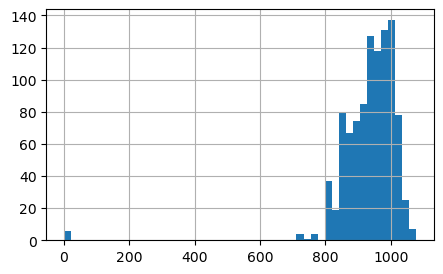

In [16]:
rolling_temp_o['rolling_temp'].hist(figsize=(5,3), bins = 50)

In [17]:
rolling_temp_o[rolling_temp_o['rolling_temp'] == 0]

,plate_no,rolling_date,scale,spec_long,spec_country,steel_kind,pt_thick,pt_width,pt_length,hsb,...,fur_heat_temp,fur_heat_time,fur_soak_temp,fur_soak_time,fur_total_time,rolling_method,rolling_temp,descaling_count,work_group,class_code
53,PLT_1054,03JAN2023:16:22:29,0,GL-E36-TM,독일,T,56,3800,11400,1,...,1132,95,1128,80,244,TMCP(온도제어),0,6,1조,GL
221,PLT_1222,04JAN2023:19:44:09,0,JS-SM490YB,일본,C,16,2200,43600,1,...,1163,57,1166,67,228,CR(제어압연),0,10,2조,JS
222,PLT_1223,04JAN2023:19:56:39,0,JS-SM490YB,일본,C,16,2200,43600,1,...,1169,64,1164,61,188,CR(제어압연),0,10,2조,JS
598,PLT_1599,07JAN2023:11:40:51,0,PILAC-BT33,한국,T,81,2100,12900,1,...,1133,89,1122,59,229,CR(제어압연),0,6,3조,KR
599,PLT_1600,07JAN2023:11:52:00,0,PILAC-BT33,한국,T,81,2100,13200,1,...,1130,92,1124,61,210,CR(제어압연),0,6,3조,KR
600,PLT_1601,07JAN2023:11:59:10,0,NV-D32-TM,영국,T,40,2500,23600,1,...,1119,109,1117,76,260,TMCP(온도제어),0,6,3조,DNV


In [18]:
# 중앙값으로 대체
find_median = rolling_temp_o[rolling_temp_o['rolling_temp'] != 0]['rolling_temp'].median()
rolling_temp_o['rolling_temp'] = rolling_temp_o['rolling_temp'].replace(0, find_median)
rolling_temp_o['rolling_temp'].describe()

count    1000.000000
mean      940.325000
std        63.665836
min       723.000000
25%       894.000000
50%       948.000000
75%       991.000000
max      1078.000000
Name: rolling_temp, dtype: float64

In [19]:
rolling_temp_o[rolling_temp_o['rolling_temp'] == 0]['rolling_temp']

Series([], Name: rolling_temp, dtype: int64)

### descaling_count
- 압연과정중 Descaling 횟수

In [20]:
descaling_count_o = rolling_temp_o.copy()
count_list = descaling_count_o['descaling_count'].value_counts()

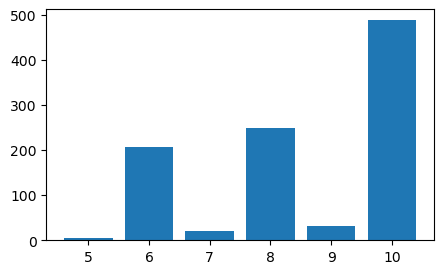

,횟수,데이터 갯수
0,10,488
3,9,31
1,8,249
4,7,20
2,6,206
5,5,6


In [21]:
plt.figure(figsize=(5, 3))
plt.bar(count_list.index, count_list.values)
plt.show()

count_df = pd.DataFrame({
    '횟수': count_list.index,
    '데이터 갯수': count_list.values
})
count_df.sort_values(by='횟수', ascending = False)

In [22]:
'''
각 홀수번 descaling을 시행한 데이터가 짝수번 시행한 데이터에 비해 각각 확연히 적으므로
5~6 : 1
7~8 : 2
9~10 : 3 으로 매핑하여 사용
'''
def dc_categorize(value):
    if  5 <=value <= 6:
        return 1
    elif 7 <=value <= 8:
        return 2
    elif 9 <=value <= 10:
        return 3

descaling_count_o['descaling_count'] = descaling_count_o['descaling_count'].apply(dc_categorize)
descaling_count_o['descaling_count'].value_counts()

3    519
2    269
1    212
Name: descaling_count, dtype: int64

## 필요 없는 데이터(열) 제거

In [23]:
drop_data = descaling_count_o.copy()
delete_col_list = ['plate_no','rolling_date','spec_long','spec_country','pt_length','fur_total_time']
drop_data.drop(columns=delete_col_list, inplace=True)
drop_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   scale            1000 non-null   int64 
 1   steel_kind       1000 non-null   object
 2   pt_thick         1000 non-null   int64 
 3   pt_width         1000 non-null   int64 
 4   hsb              1000 non-null   int64 
 5   fur_no           1000 non-null   object
 6   fur_input_row    1000 non-null   object
 7   fur_heat_temp    1000 non-null   int64 
 8   fur_heat_time    1000 non-null   int64 
 9   fur_soak_temp    1000 non-null   int64 
 10  fur_soak_time    1000 non-null   int64 
 11  rolling_method   1000 non-null   object
 12  rolling_temp     1000 non-null   int64 
 13  descaling_count  1000 non-null   int64 
 14  work_group       1000 non-null   object
 15  class_code       1000 non-null   object
dtypes: int64(10), object(6)
memory usage: 125.1+ KB


In [24]:
drop_data.describe()

,scale,pt_thick,pt_width,hsb,fur_heat_temp,fur_heat_time,fur_soak_temp,fur_soak_time,rolling_temp,descaling_count
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.310000,26.78200,2831.900000,0.953000,1157.245000,85.972000,1150.928000,71.720000,940.325000,2.307000
std,0.462725,18.13757,494.081478,0.211745,21.245007,26.346297,17.344384,20.602137,63.665836,0.798366
min,0.000000,12.00000,1800.000000,0.000000,1103.000000,55.000000,1113.000000,35.000000,723.000000,1.000000
25%,0.000000,15.00000,2500.000000,1.000000,1140.000000,66.000000,1135.750000,57.750000,894.000000,2.000000
50%,0.000000,19.00000,2800.000000,1.000000,1159.000000,75.000000,1156.000000,66.000000,948.000000,3.000000
75%,1.000000,34.00000,3100.000000,1.000000,1173.000000,102.250000,1164.000000,81.000000,991.000000,3.000000
max,1.000000,100.00000,4600.000000,1.000000,1206.000000,158.000000,1185.000000,145.000000,1078.000000,3.000000


In [25]:
drop_data.head()

,scale,steel_kind,pt_thick,pt_width,hsb,fur_no,fur_input_row,fur_heat_temp,fur_heat_time,fur_soak_temp,fur_soak_time,rolling_method,rolling_temp,descaling_count,work_group,class_code
0,0,T,32,3700,1,1호기,1열,1144,116,1133,59,TMCP(온도제어),934,2,1조,ABS
1,0,T,32,3700,1,1호기,2열,1144,122,1135,53,TMCP(온도제어),937,2,1조,ABS
2,0,T,33,3600,1,2호기,1열,1129,116,1121,55,TMCP(온도제어),889,2,1조,DNV
3,0,T,33,3600,1,2호기,2열,1152,125,1127,68,TMCP(온도제어),885,2,1조,DNV
4,0,T,38,3100,1,3호기,1열,1140,134,1128,48,TMCP(온도제어),873,2,1조,BV


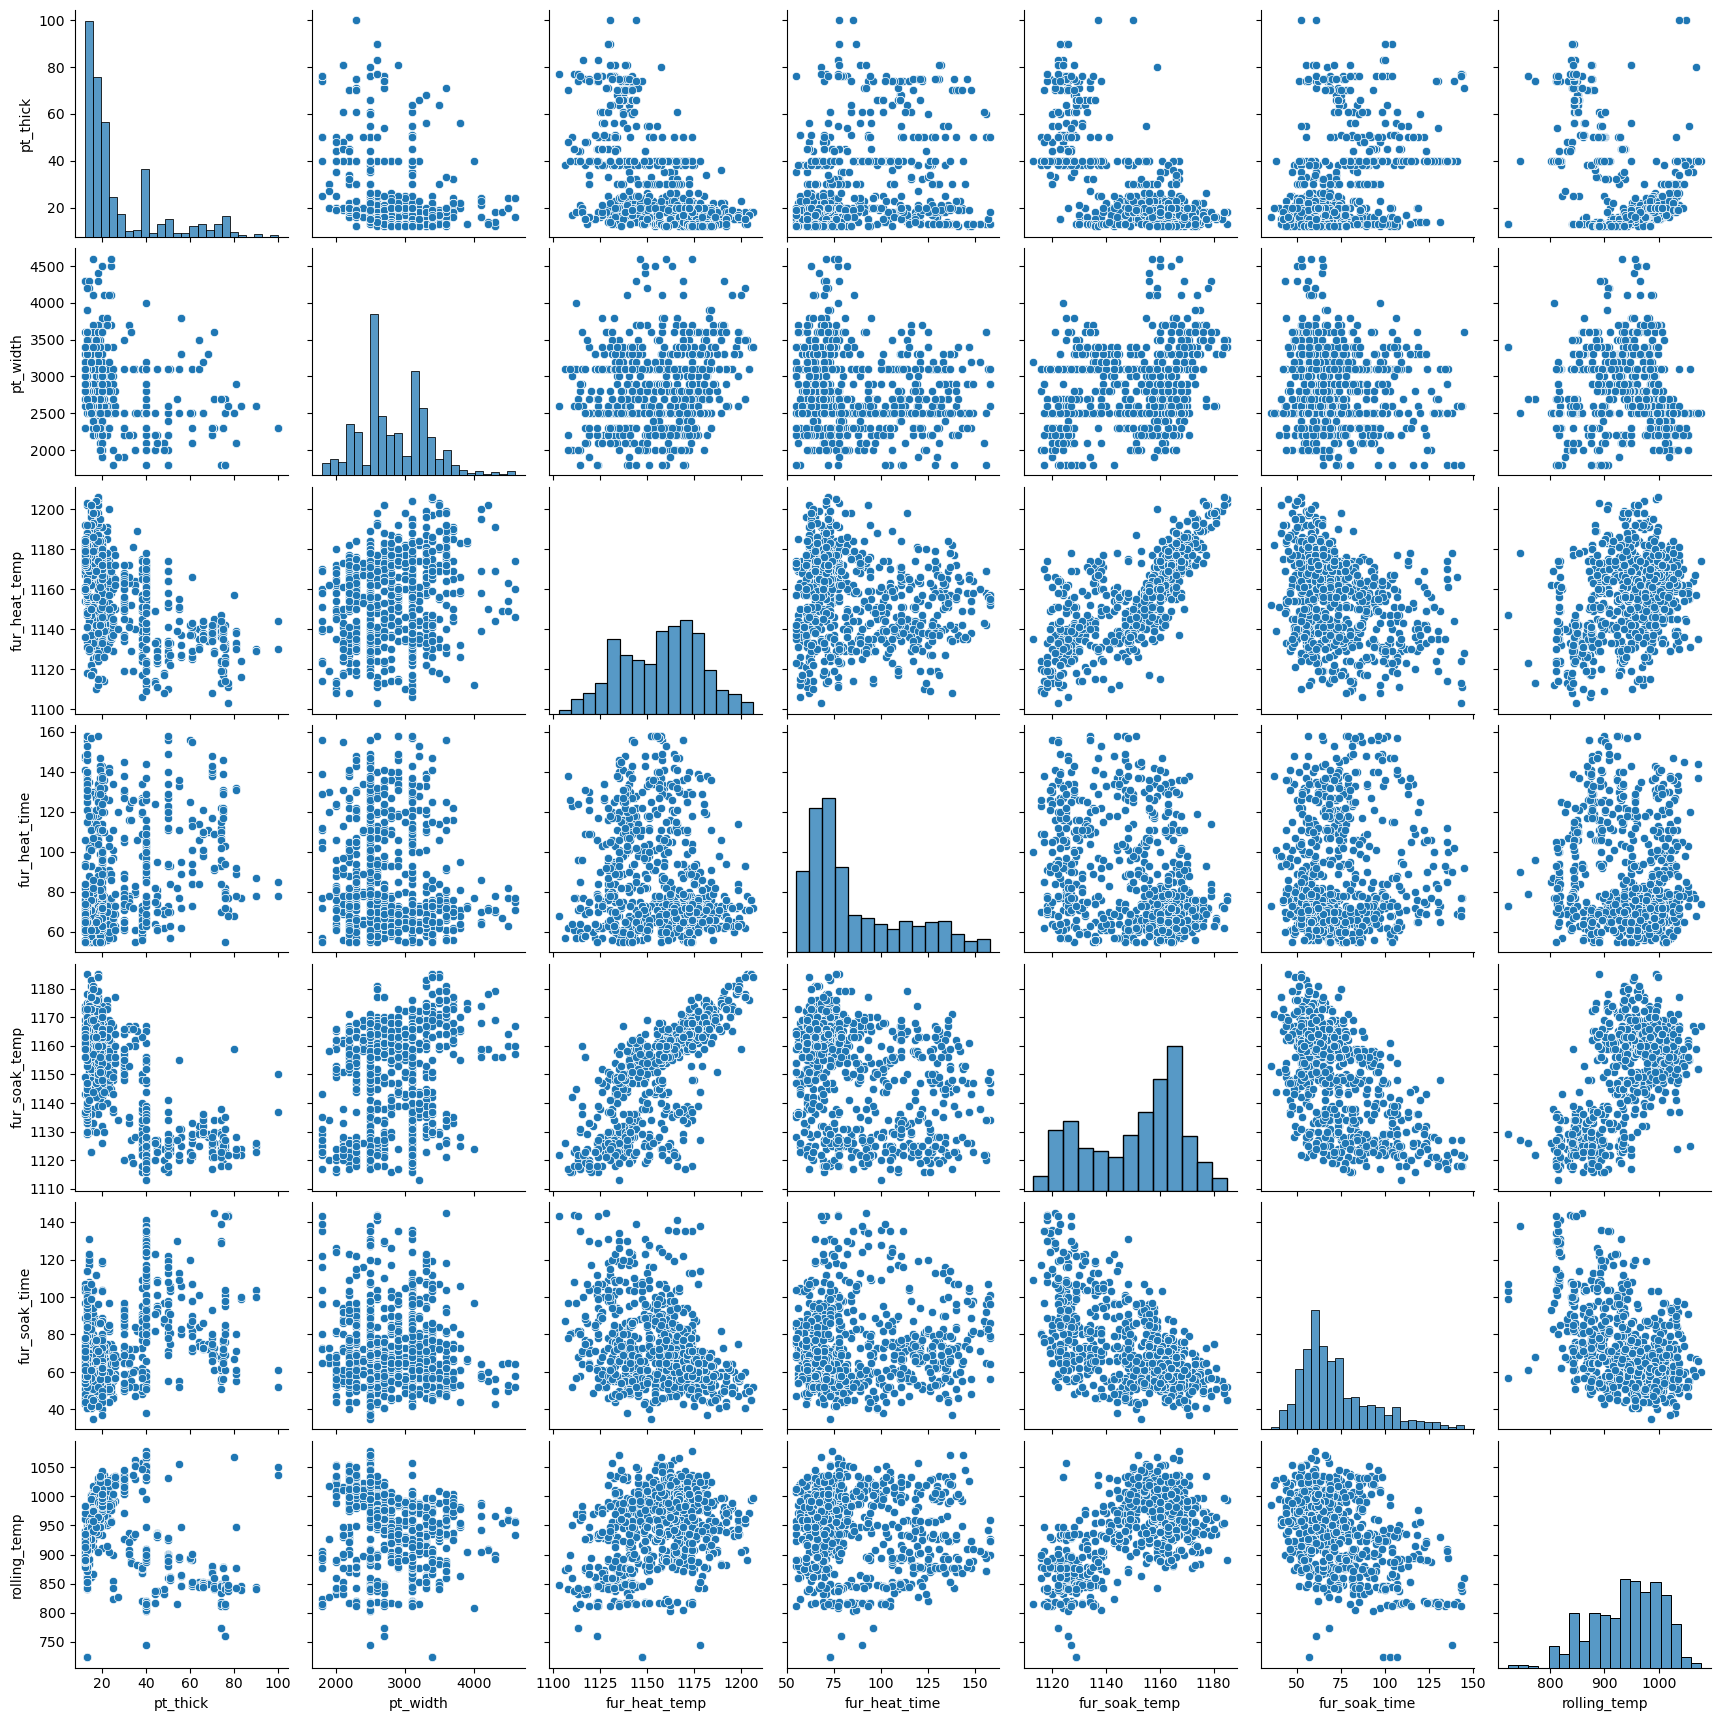

In [26]:
subset_df = drop_data[['pt_thick','pt_width','fur_heat_temp','fur_heat_time',
                       'fur_soak_temp','fur_soak_time','rolling_temp',]]
sns.pairplot(subset_df)
plt.show()

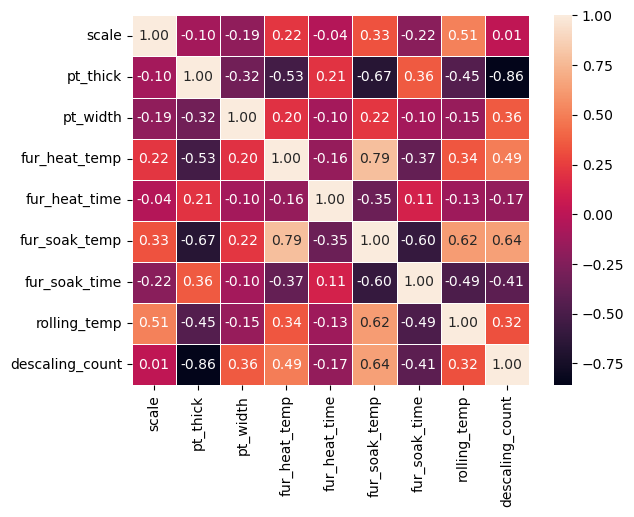

In [27]:
subset_df = drop_data[['scale','pt_thick','pt_width','fur_heat_temp','fur_heat_time',
                       'fur_soak_temp','fur_soak_time','rolling_temp','descaling_count']]
correlation_matrix = subset_df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", linewidths=0.5)
plt.show()

## Dummy 함수 만들기


In [33]:
before_dummy_o = drop_data.copy()
dummy_col_list = ['steel_kind', 'fur_no', 'fur_input_row', 
                  'rolling_method', 'work_group', 'class_code']
make_dummy = pd.get_dummies(before_dummy_o[dummy_col_list])
final_data = pd.concat([before_dummy_o.drop(columns=dummy_col_list), make_dummy], axis=1)

In [34]:
feature_select_data = drop_data.copy()
drop_cols_list = ['hsb','fur_no','fur_input_row','descaling_count']

feature_select_data.drop(columns = drop_cols_list, inplace = True)
dummy_col_list = ['steel_kind', 'rolling_method', 'work_group', 'class_code']
make_dummy_fe = pd.get_dummies(feature_select_data[dummy_col_list])
final_data_fe = pd.concat([feature_select_data.drop(columns=dummy_col_list), make_dummy_fe], axis=1)
final_data_fe.head()

,scale,pt_thick,pt_width,fur_heat_temp,fur_heat_time,fur_soak_temp,fur_soak_time,rolling_temp,steel_kind_C,steel_kind_T,...,class_code_BV,class_code_CCS,class_code_Common,class_code_DNV,class_code_GL,class_code_JS,class_code_KR,class_code_KS,class_code_LR,class_code_NK
0,0,32,3700,1144,116,1133,59,934,0,1,...,0,0,0,0,0,0,0,0,0,0
1,0,32,3700,1144,122,1135,53,937,0,1,...,0,0,0,0,0,0,0,0,0,0
2,0,33,3600,1129,116,1121,55,889,0,1,...,0,0,0,1,0,0,0,0,0,0
3,0,33,3600,1152,125,1127,68,885,0,1,...,0,0,0,1,0,0,0,0,0,0
4,0,38,3100,1140,134,1128,48,873,0,1,...,1,0,0,0,0,0,0,0,0,0


### 파생데이터
1. dummy : tree모델
2. dummy + scaling : SVM, NN, Log-Reg
3. 카테고리 + scaling : Log-Reg

In [35]:
# 기본데이터
final_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 36 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   scale                      1000 non-null   int64
 1   pt_thick                   1000 non-null   int64
 2   pt_width                   1000 non-null   int64
 3   hsb                        1000 non-null   int64
 4   fur_heat_temp              1000 non-null   int64
 5   fur_heat_time              1000 non-null   int64
 6   fur_soak_temp              1000 non-null   int64
 7   fur_soak_time              1000 non-null   int64
 8   rolling_temp               1000 non-null   int64
 9   descaling_count            1000 non-null   int64
 10  steel_kind_C               1000 non-null   uint8
 11  steel_kind_T               1000 non-null   uint8
 12  fur_no_1호기                 1000 non-null   uint8
 13  fur_no_2호기                 1000 non-null   uint8
 14  fur_no_3호기               

In [37]:
# scaler + dummy

from sklearn.preprocessing import StandardScaler
stdscaler = StandardScaler()
scaling_cols = ['pt_thick', 'pt_width', 'fur_heat_temp',
       'fur_heat_time', 'fur_soak_temp', 'fur_soak_time', 'rolling_temp']

for_scaled_dummy_data = final_data.copy()
data_scaled = pd.DataFrame(stdscaler.fit_transform(for_scaled_dummy_data[scaling_cols]), columns=scaling_cols)

scaled_dummy_data = pd.concat([data_scaled, for_scaled_dummy_data.drop(columns=scaling_cols)], axis = 1)
scaled_dummy_data = scaled_dummy_data[final_data.columns]
scaled_dummy_data.head()


,scale,pt_thick,pt_width,hsb,fur_heat_temp,fur_heat_time,fur_soak_temp,fur_soak_time,rolling_temp,descaling_count,...,class_code_BV,class_code_CCS,class_code_Common,class_code_DNV,class_code_GL,class_code_JS,class_code_KR,class_code_KS,class_code_LR,class_code_NK
0,0,0.287834,1.757877,1,-0.623753,1.140313,-1.034166,-0.617721,-0.099397,2,...,0,0,0,0,0,0,0,0,0,0
1,0,0.287834,1.757877,1,-0.623753,1.368163,-0.918797,-0.909098,-0.052252,2,...,0,0,0,0,0,0,0,0,0,0
2,0,0.342996,1.555380,1,-1.330154,1.140313,-1.726379,-0.811972,-0.806566,2,...,0,0,0,1,0,0,0,0,0,0
3,0,0.342996,1.555380,1,-0.247005,1.482088,-1.380272,-0.180654,-0.869425,2,...,0,0,0,1,0,0,0,0,0,0
4,0,0.618805,0.542895,1,-0.812126,1.823863,-1.322588,-1.151913,-1.058004,2,...,1,0,0,0,0,0,0,0,0,0


In [38]:
# scaler + dummy
stdscaler = StandardScaler()

for_scaled_dummy_data_fe = final_data_fe.copy()
data_scaled_fe = pd.DataFrame(stdscaler.fit_transform(for_scaled_dummy_data_fe[scaling_cols]), columns=scaling_cols)

scaled_dummy_data_fe = pd.concat([data_scaled_fe, for_scaled_dummy_data_fe.drop(columns=scaling_cols)], axis = 1)
scaled_dummy_data_fe = scaled_dummy_data_fe[final_data_fe.columns]
scaled_dummy_data_fe.head()

,scale,pt_thick,pt_width,fur_heat_temp,fur_heat_time,fur_soak_temp,fur_soak_time,rolling_temp,steel_kind_C,steel_kind_T,...,class_code_BV,class_code_CCS,class_code_Common,class_code_DNV,class_code_GL,class_code_JS,class_code_KR,class_code_KS,class_code_LR,class_code_NK
0,0,0.287834,1.757877,-0.623753,1.140313,-1.034166,-0.617721,-0.099397,0,1,...,0,0,0,0,0,0,0,0,0,0
1,0,0.287834,1.757877,-0.623753,1.368163,-0.918797,-0.909098,-0.052252,0,1,...,0,0,0,0,0,0,0,0,0,0
2,0,0.342996,1.555380,-1.330154,1.140313,-1.726379,-0.811972,-0.806566,0,1,...,0,0,0,1,0,0,0,0,0,0
3,0,0.342996,1.555380,-0.247005,1.482088,-1.380272,-0.180654,-0.869425,0,1,...,0,0,0,1,0,0,0,0,0,0
4,0,0.618805,0.542895,-0.812126,1.823863,-1.322588,-1.151913,-1.058004,0,1,...,1,0,0,0,0,0,0,0,0,0


In [100]:
# scaler + 카테고리

stdscaler = StandardScaler()
scaling_cols = ['pt_thick', 'pt_width', 'fur_heat_temp',
       'fur_heat_time', 'fur_soak_temp', 'fur_soak_time', 'rolling_temp']

for_scaled_data = drop_data.copy()
data_scaled = pd.DataFrame(stdscaler.fit_transform(for_scaled_data[scaling_cols]), columns=scaling_cols)

scaled_data = pd.concat([data_scaled, for_scaled_data.drop(columns=scaling_cols)], axis = 1)
scaled_data = scaled_data[drop_data.columns]
display(scaled_data.head())

,scale,steel_kind,pt_thick,pt_width,hsb,fur_no,fur_input_row,fur_heat_temp,fur_heat_time,fur_soak_temp,fur_soak_time,rolling_method,rolling_temp,descaling_count,work_group,class_code
0,0,T,0.287834,1.757877,1,1호기,1열,-0.623753,1.140313,-1.034166,-0.617721,TMCP(온도제어),-0.099397,2,1조,ABS
1,0,T,0.287834,1.757877,1,1호기,2열,-0.623753,1.368163,-0.918797,-0.909098,TMCP(온도제어),-0.052252,2,1조,ABS
2,0,T,0.342996,1.555380,1,2호기,1열,-1.330154,1.140313,-1.726379,-0.811972,TMCP(온도제어),-0.806566,2,1조,DNV
3,0,T,0.342996,1.555380,1,2호기,2열,-0.247005,1.482088,-1.380272,-0.180654,TMCP(온도제어),-0.869425,2,1조,DNV
4,0,T,0.618805,0.542895,1,3호기,1열,-0.812126,1.823863,-1.322588,-1.151913,TMCP(온도제어),-1.058004,2,1조,BV


## 데이터 저장하기

In [91]:
# 기본 for tree
final_data.to_csv("./B1_종합실습2_전처리데이터(Tree).csv", index=False)

In [92]:
# scaler + dummy for svm, nn
scaled_dummy_data.to_csv("./B1_종합실습2_전처리데이터(SVM_NN).csv",index = False)

In [93]:
# scaler + category for logit
scaled_data.to_csv("./B1_종합실습2_전처리데이터(Logit_reg).csv", index = False)

In [31]:
# feature 선택 후 데이터셋, for tree
final_data_fe.to_csv("./B1_종합실습2_전처리데이터(2차_tree).csv", index = False)

In [39]:
# feature 선택 후 데이터셋, for tree
final_data_fe.to_csv("./B1_종합실습2_전처리데이터(2차_tree).csv", index = False)

In [40]:
# feature 선택 후 데이터셋, for svm, nn
scaled_dummy_data_fe.to_csv("./B1_종합실습2_전처리데이터(2차_svm_nn).csv", index = False)